In [25]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict, Optional
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'binh_thuong':0,
            'dut_ban_phan_1_3_giua':1,
            'dut_hoan_toan_1_3_giua':2,
            'dut_ban_phan_1_3_duoi':3,
            'dut_hoan_toan_1_3_duoi':4,
            'dut_ban_phan_1_3_tren':5,
            'dut_hoan_toan_1_3_tren':6
            }
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.01,0.001,0.0001]
        },
        'epoch':{
            'values':[20,30,40]
        },
        'batch_size':{
            'values':[2,4,8,16]
        }
    }
}

Scanning folder: 2025_14_11_Thanh
Number of selected files: 19
Scanning folder: 2025_22_11_Thuan
Number of selected files: 20
Scanning folder: 2026_18_1_Thuan
Number of selected files: 16
Scanning folder: 2026_1_2_Thanh
Number of selected files: 20
Scanning folder: 26_01_02_Thanh
Number of selected files: 22
Scanning folder: 26_16_02_Thuan
Number of selected files: 52
Scanning folder: 26_27_02_Thanh
Number of selected files: 20

ACL type distribution:
Total patient: 169
dut_ban_phan_1_3_giua: 30
dut_hoan_toan_1_3_giua: 29
dut_ban_phan_1_3_duoi: 17
dut_hoan_toan_1_3_tren: 32
dut_ban_phan_1_3_tren: 21
binh_thuong: 37
segment_1: 3


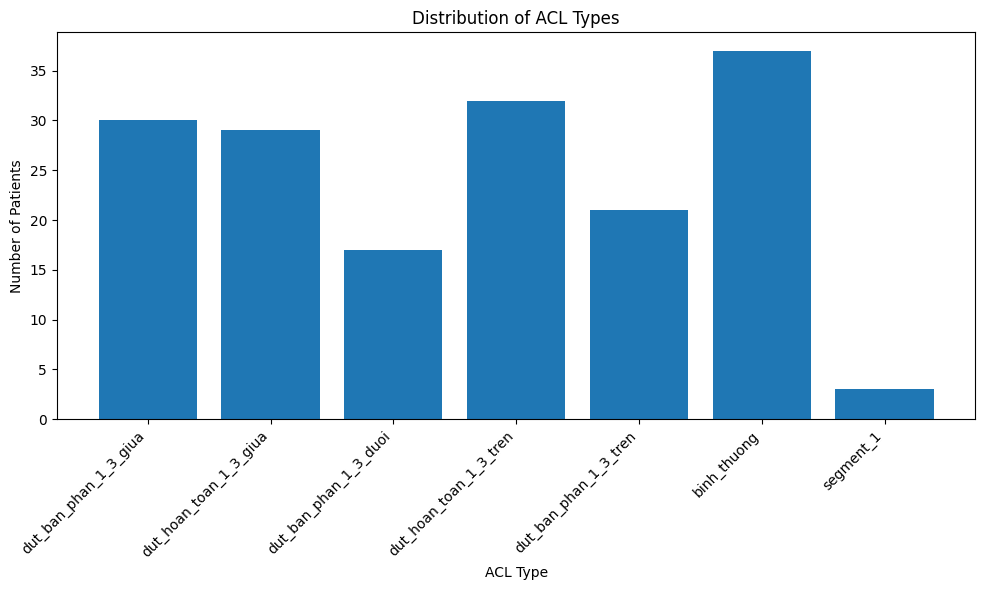

In [27]:
class ACLDataCollector:
    def __init__(
        self,
        root_dir: str,
        pattern: str,
        segment_signal_string: str,
        image_keyword: str = "t2_tse_sag",
        seg_keyword: str = "Segmentation*.seg.nrrd",
    ):
        self.root_dir = Path(root_dir)
        self.pattern = re.compile(pattern)
        self.segment_signal_string = segment_signal_string
        self.image_keyword = image_keyword.lower()
        self.seg_keyword = seg_keyword
        self.all_patients: Dict[str, Dict] = {}
        self.type_count: Dict[str, int] = {}

    def get_acl_indices(self, seg_header: dict):
        seg_indices = []
        for k in seg_header.keys():
            m = self.pattern.match(k)
            if m:
                seg_indices.append(m.group(1))
        return seg_indices

    def get_acl_type(self, seg_header: Dict) -> Optional[str]:
        indices = self.get_acl_indices(seg_header)
        for idx in indices:
            tag_key = f"Segment{idx}_Tags"
            name_key = f"Segment{idx}_Name"

            if tag_key in seg_header and name_key in seg_header:
                value = str(seg_header[tag_key])
                if value.startswith(self.segment_signal_string):
                    return str(seg_header[name_key]).lower()
        return None

    def collect_data_and_seg(self, folder_path: Path) -> Dict:
        result = {}
        for subfolder in folder_path.iterdir():
            if not subfolder.is_dir():
                continue
            seg_files = sorted(subfolder.glob(self.seg_keyword))
            t2_files = sorted(
                p for p in subfolder.glob("*.nrrd")
                if self.image_keyword in p.stem.lower()
            )
            if not seg_files or not t2_files:
                continue
            _, seg_header = nrrd.read(str(seg_files[0]))
            acl_type = self.get_acl_type(seg_header)

            result[subfolder.name] = {
                "nrrd": str(t2_files[0]),
                "seg": str(seg_files[0]),
                "type": acl_type,
            }
        return result
    def collect_all(self) -> Dict:
        self.all_patients = {}
        for sub_folder in self.root_dir.iterdir():
            if not sub_folder.is_dir():
                continue
            print(f"Scanning folder: {sub_folder.name}")
            data_dict = self.collect_data_and_seg(sub_folder)
            self.all_patients.update(data_dict)
            print(f"Number of selected files: {len(data_dict)}")
        return self.all_patients

    def count_acl_types(self) -> Dict[str, int]:
        self.type_count = {}
        for _, data in self.all_patients.items():
            acl_type = data["type"] if data["type"] is not None else "unknown"
            self.type_count[acl_type] = self.type_count.get(acl_type, 0) + 1
        return self.type_count
    
    def print_summary(self):
        if not self.type_count:
            self.count_acl_types()
        print("\nACL type distribution:")
        print(f"Total patient: {len(self.all_patients)}")
        for k, v in self.type_count.items():
            print(f"{k}: {v}")

    def plot_distribution(self):
        if not self.type_count:
            self.count_acl_types()

        labels = list(self.type_count.keys())
        counts = list(self.type_count.values())

        plt.figure(figsize=(10, 6))
        plt.bar(labels, counts)
        plt.xlabel("ACL Type")
        plt.ylabel("Number of Patients")
        plt.title("Distribution of ACL Types")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
 
    collector = ACLDataCollector(
        root_dir=r"D:\Project\ACL\my_tool\data",
        pattern=pattern,
        segment_signal_string=Segment_signal_string
    )

    all_patients=collector.collect_all()
    collector.count_acl_types()
    collector.print_summary()
    collector.plot_distribution()

In [28]:
class MRI_data(Dataset):
    def __init__(
        self,
        data_dict: Dict,
        img_trasform=None,
        label_transform=None,
        target_size=(320,320),
        target_depth=25
    ):
        self.data_dict = data_dict
        self.img_transform = img_trasform
        self.label_transform = label_transform
        self.target_size = target_size
        self.target_depth = target_depth
        self.samples = []
        num_patient = 0
        for patient, data in data_dict.items():
            nrrd_path = data['nrrd']
            seg_path = data['seg']
            nrrd_data, _ = nrrd.read(nrrd_path)
            seg_data, _ = nrrd.read(seg_path)
            type_acl = data['type']
            #Extract the middle slice
            num_slices=nrrd_data.shape[2]
            start_slice,end_slice=self.calculate_middle_slices(num_slices,8)
            nrrd_data=nrrd_data[:,:,start_slice:end_slice]
            #Skipping error label
            if type_acl == 'segment_1':
                print("Skipping segment_1 label")
                continue
            if nrrd_data.shape[0]!=352:
                print("Skipping non 352x352 image")
                continue 
            #Divide into 3 classes
            classes=label_type[type_acl]
            if classes==0:
                classes=0
            elif classes in [1,3,5]:
                classes=1
            else:
                classes=2
            #return patients samples
            self.samples.append((nrrd_data, classes))
            num_patient += 1
        print(f"Number of patient selected / total: {num_patient}/{len(data_dict)}")

    def __len__(self):
        return len(self.samples)

    def fix_depth(self, volume):
        H, W, D = volume.shape
        if D > self.target_depth:
            start = (D - self.target_depth) // 2
            volume = volume[:, :, start:start + self.target_depth]
        elif D < self.target_depth:
            pad = self.target_depth - D
            pad_before = pad // 2
            pad_after = pad - pad_before
            volume = np.pad(
                volume,
                ((0,0),(0,0),(pad_before,pad_after)),
                mode="constant"
            )
        return volume
    
    def calculate_middle_slices(self,num_slices,target_slices):
        start=(num_slices-target_slices)//2
        end=start+target_slices
        return start,end
    
    def __getitem__(self, index):

        img, label = self.samples[index]
        # normalize
        img = img / (np.max(img) + 1e-8)
        # fix slice depth
        img = self.fix_depth(img)
        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)  # (D,H,W)
        img = img.unsqueeze(0)  # (1,D,H,W)
        label = torch.tensor(label, dtype=torch.long)

        if self.img_transform:
            img = self.img_transform(img)

        if self.label_transform:
            label = self.label_transform(label)
        return img, label

In [29]:
img_transform=transforms.Compose([
    transforms.Resize((320,320)),
])
dataset=MRI_data(data_dict=all_patients,img_trasform=img_transform)

Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping segment_1 label
Skipping segment_1 label
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping segment_1 label
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skipping non 352x352 image
Skippin

In [30]:
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")

Dataset length: 104
Sample image shape: torch.Size([1, 25, 320, 320]), Sample label: 0


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MRI_3D_CNN(nn.Module):
    def __init__(self, num_classes: int = 3, in_channels: int = 1):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv3d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),   # [D,H,W] -> [D/2,H/2,W/2]

            # Block 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            # Make output size fixed regardless of input spatial size
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),              # [B,128,1,1,1] -> [B,128]
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        x shape: [B, C, D, H, W]
        """
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
model = MRI_3D_CNN(num_classes=3, in_channels=1)
print(model)

MRI_3D_CNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (13): BatchNorm3

In [33]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 83
Validation set size: 21


Overall Dataset Label Distribution:


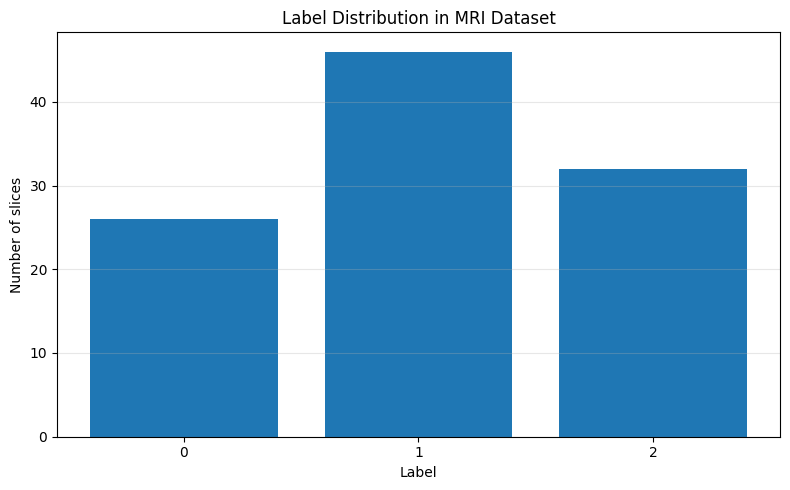

Label 0: 26 samples
Label 1: 46 samples
Label 2: 32 samples
Training Set Label Distribution:


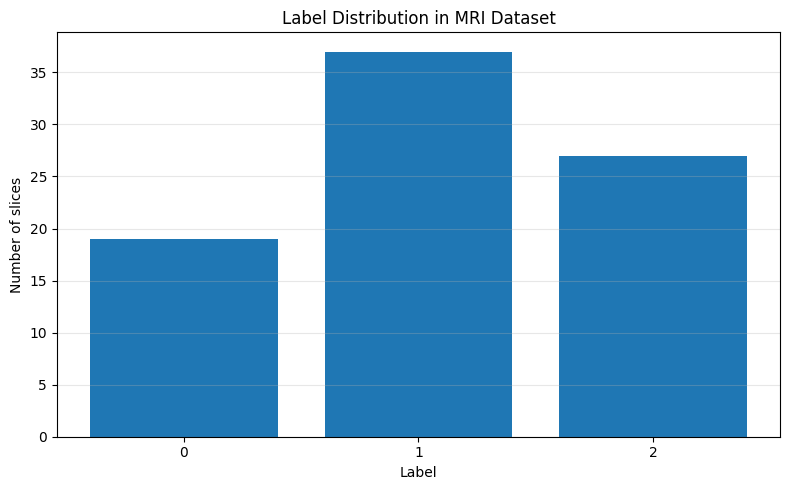

Label 0: 19 samples
Label 1: 37 samples
Label 2: 27 samples
Validation Set Label Distribution:


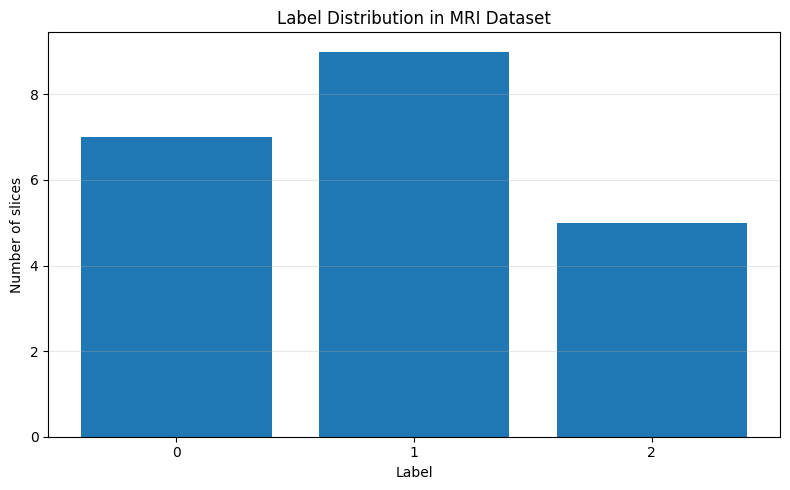

Label 0: 7 samples
Label 1: 9 samples
Label 2: 5 samples


In [34]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [35]:
wandb.login()

True

In [36]:
class TrainerWB:
    def __init__(self, config, train_loader, val_loader, model, class_weights=None):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.epochs = config.epoch
        self.learning_rate = config.lr
        self.batch_size = config.batch_size

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model = model.to(self.device)

        if class_weights is not None:
            class_weights = class_weights.to(self.device)
            self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(),lr=self.learning_rate)


    def _run_one_epoch(self):
        self.model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(self.train_loader, desc="Training", leave=False)

        for images, labels in progress_bar:
            images = images.to(self.device)
            labels = labels.to(self.device)

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

            progress_bar.set_postfix(
                loss=running_loss / total,
                acc=correct / total
            )

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def _validate_one_epoch(self):
        self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                batch_size = images.size(0)
                running_loss += loss.item() * batch_size

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += batch_size

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        cm = confusion_matrix(all_labels, all_preds)

        return epoch_loss, epoch_acc, cm, all_labels, all_preds

    def fit(self, print_every=1, show_confusion_matrix_every=5):
        for epoch in range(1, self.epochs + 1):
            train_loss, train_acc = self._run_one_epoch()
            val_loss, val_acc, cm, all_labels, all_preds = self._validate_one_epoch()
            if epoch % print_every == 0:
                print(f"\nEpoch [{epoch}/{self.epochs}]")
                print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
                print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
            if epoch % show_confusion_matrix_every == 0:
                print("\nConfusion Matrix:")
                print(cm)

            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc
            })

        print("Training complete.")

In [37]:
def main():
    with wandb.init(project="ACL_Classification_3D_CNN", reinit=True):
        config=wandb.config
        train_loader = DataLoader(train_dataset,batch_size=config.batch_size,shuffle=True)
        val_loader = DataLoader(val_dataset,batch_size=config.batch_size,shuffle=False)
        trainer = TrainerWB(
            config=wandb.config,
            train_loader=train_loader,
            val_loader=val_loader,
            model=model
        )
        trainer.fit(print_every=5,show_confusion_matrix_every=5)

In [38]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification_3D_CNN_352x352")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: lrqek1ii
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification_3D_CNN_352x352/sweeps/lrqek1ii


wandb: Agent Starting Run: b31cf5ar with config:
wandb: 	batch_size: 16
wandb: 	epoch: 20
wandb: 	lr: 0.01



Epoch [5/20]
Train Loss: 1.0396, Train Acc: 0.4337
Val Loss:   1.0992, Val Acc:   0.3333

Confusion Matrix:
[[6 1 0]
 [8 1 0]
 [4 1 0]]



Epoch [10/20]
Train Loss: 1.0201, Train Acc: 0.4458
Val Loss:   1.0850, Val Acc:   0.4286

Confusion Matrix:
[[0 7 0]
 [0 9 0]
 [0 5 0]]



Epoch [15/20]
Train Loss: 1.0586, Train Acc: 0.4337
Val Loss:   1.1103, Val Acc:   0.4286

Confusion Matrix:
[[0 7 0]
 [0 9 0]
 [0 5 0]]



Epoch [20/20]
Train Loss: 1.0404, Train Acc: 0.4458
Val Loss:   1.1159, Val Acc:   0.4286

Confusion Matrix:
[[0 7 0]
 [0 9 0]
 [0 5 0]]
Training complete.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▂▅▇▆▆▂▇▁█▇▇▅▇▅▆▇▇▆▇▇
train_loss,█▅▃▃▂▅▄▄▃▁▂▅▄▃▄▂▄▂▃▃
val_acc,▆▆▆▆▁▃▆▆▆▆▆▆█▆▆▆▆▆▆▆
val_loss,▃▂▁▂▂▂▂▂▃▁▁▁▁▂▂█▇▂▂▂
epoch,20
train_acc,0.44578
train_loss,1.04036
val_acc,0.42857
val_loss,1.1159


wandb: Ctrl + C detected. Stopping sweep.
